In [4]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [5]:
# ==========================================
# 2. CARGA Y LIMPIEZA TOTAL DE DATOS
# ==========================================
ruta = 'all_games.csv'
df_final = pd.read_csv(ruta)


In [7]:
# SOLUCIÓN AL ERROR 'tbd': Convertimos user_review a numérico. 
# Los valores 'tbd' se convertirán en NaN (nulos) para ser eliminados.
df_final['user_review'] = pd.to_numeric(df_final['user_review'], errors='coerce')



In [8]:
# Eliminamos filas con valores nulos para que el algoritmo pueda procesar los datos
df_final = df_final.dropna(subset=['meta_score', 'user_review'])


In [9]:
# Limpieza de espacios en blanco en los nombres de plataforma
df_final['platform'] = df_final['platform'].str.strip()


In [10]:
# ==========================================
# 3. ESCALADO DE DATOS (Pre-procesamiento Crítico)
# ==========================================
# Normalizamos las escalas (Meta Score 0-100 y User Review 0-10)
scaler = StandardScaler()
features = df_final[['meta_score', 'user_review']]
features_scaled = scaler.fit_transform(features)


In [14]:
# ==========================================
# 4. ENTRENAMIENTO DEL MODELO (K-Means)
# ==========================================
# Agrupamos en 3 segmentos: Juegos de Culto, Blockbusters y otros
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(features_scaled)


In [15]:
# ==========================================
# 5. EVALUACIÓN Y PERFILAMIENTO (Checkpoint de Calidad)
# ==========================================
print("--- Perfil Promedio de los Segmentos ---")
perfiles = df_final.groupby('cluster')[['meta_score', 'user_review']].mean()
print(perfiles)


--- Perfil Promedio de los Segmentos ---
         meta_score  user_review
cluster                         
0         80.613832     7.896478
1         66.862304     6.832847
2         54.112647     4.588329


In [16]:
# Coeficiente de Silueta: Validación técnica de la cohesión de los grupos
score = silhouette_score(features_scaled, df_final['cluster'])
print(f"\nCoeficiente de Silueta: {score:.4f}")

# Localización de Centroides en escala original para interpretación de negocio
centroides_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\n--- Ubicación de Centroides (Escala Real) ---")
for i, centro in enumerate(centroides_original):
    print(f"Cluster {i}: Meta Score {centro[0]:.2f}, User Review {centro[1]:.2f}")




Coeficiente de Silueta: 0.3652

--- Ubicación de Centroides (Escala Real) ---
Cluster 0: Meta Score 80.62, User Review 7.90
Cluster 1: Meta Score 66.90, User Review 6.83
Cluster 2: Meta Score 54.09, User Review 4.59


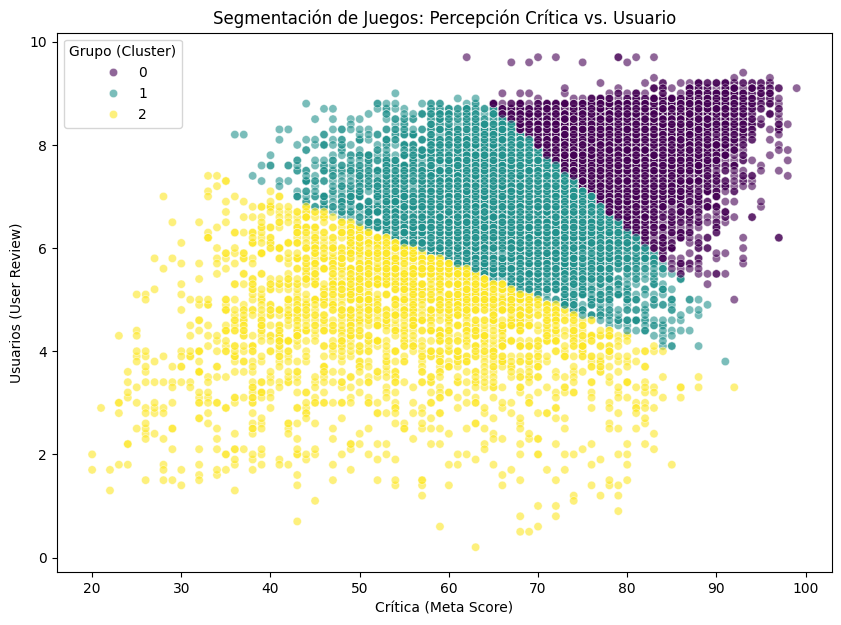

In [17]:
# ==========================================
# 6. VISUALIZACIÓN DE LOS SEGMENTOS
# ==========================================
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='meta_score', y='user_review', 
                hue='cluster', palette='viridis', alpha=0.6)
plt.title('Segmentación de Juegos: Percepción Crítica vs. Usuario')
plt.xlabel('Crítica (Meta Score)')
plt.ylabel('Usuarios (User Review)')
plt.legend(title='Grupo (Cluster)')
plt.show()
